### RNN을 이어 붙인 seq2seq(Encoder-Decoder)

1. RNN 모델 1개를 활용해 문장 생성 언어 모델(LSTM)
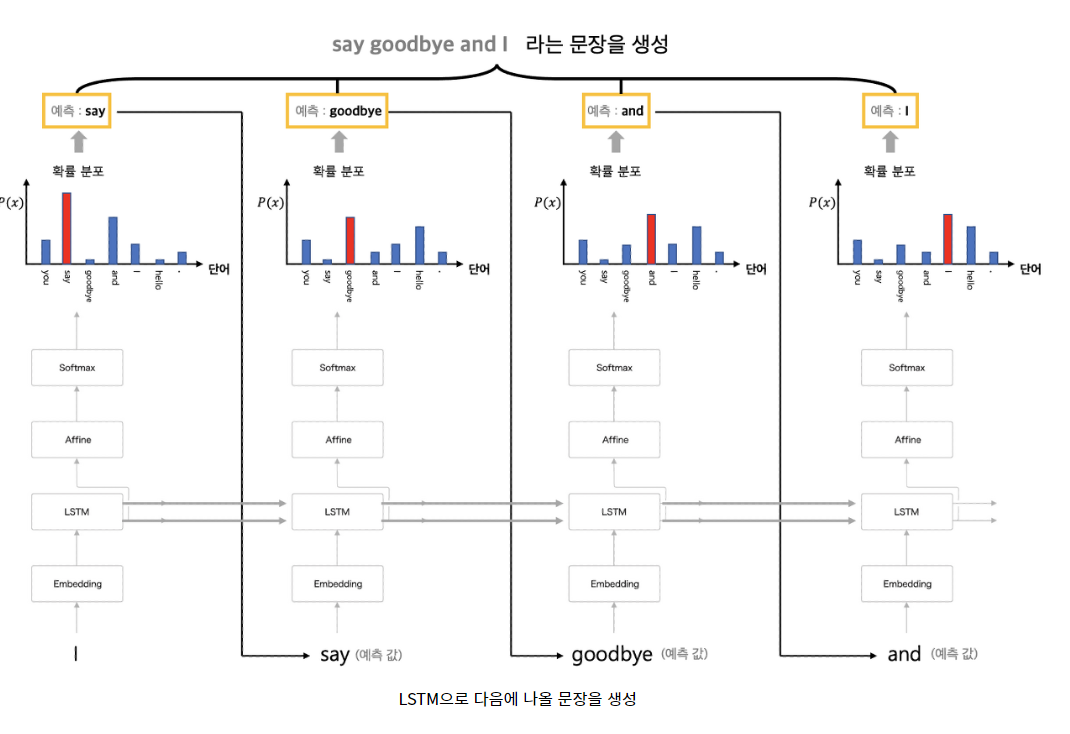

#### RNN 2개를 연결한 seq2seq
- 입력으로 시퀀스(시계열) 데이터를 넣어주면 또 다른 시퀀스 데이터를 출력으로 내뱉는 데 자주 사용되는 모델

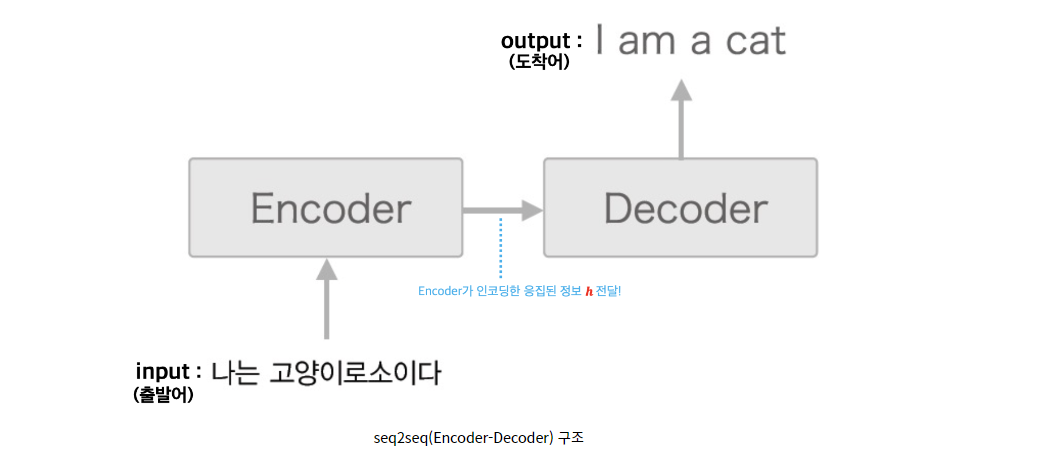

#### RNN 신경망으로 구성되는 Encoder

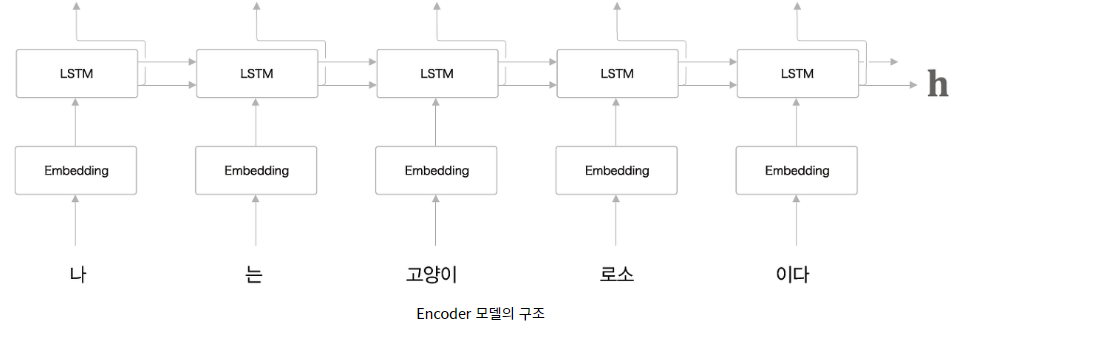

- 순환하면서 결국 마지막에 ℎ라는 마지막(으로 순환하는) LSTM 계층의 은닉상태 벡터를 출력
- 마지막 ℎ에는 입력 문장에 대한 필요한 정보가 인코딩 되어 있음

- 하나의 Encoder 모델이 내뱉는 ℎ벡터의 길이
    - 어떤 길이의 입력이 Encoder 모델에 들어왔다고 해도 반드시 ℎ벡터의 길이는 동일해야 한다

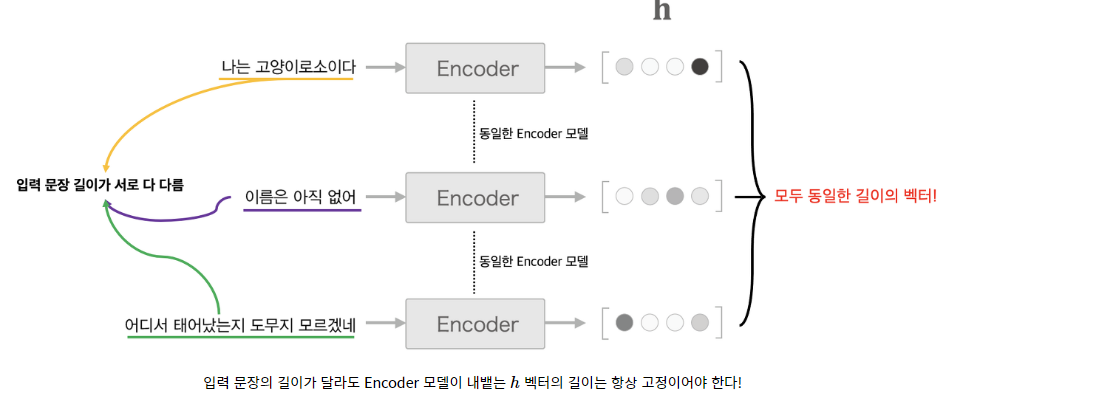

#### Encoder의 정보를 전달 받는 RNN 신경망(Decoder)
- Encoder의 최종 은닉 상태 벡터인 ℎ를 전달받는 RNN 신경망 모델
- 즉, Encoder가 전달해준 ℎ를 RNN 입력으로 넣어주어 '도착어'를 생성하는 모델

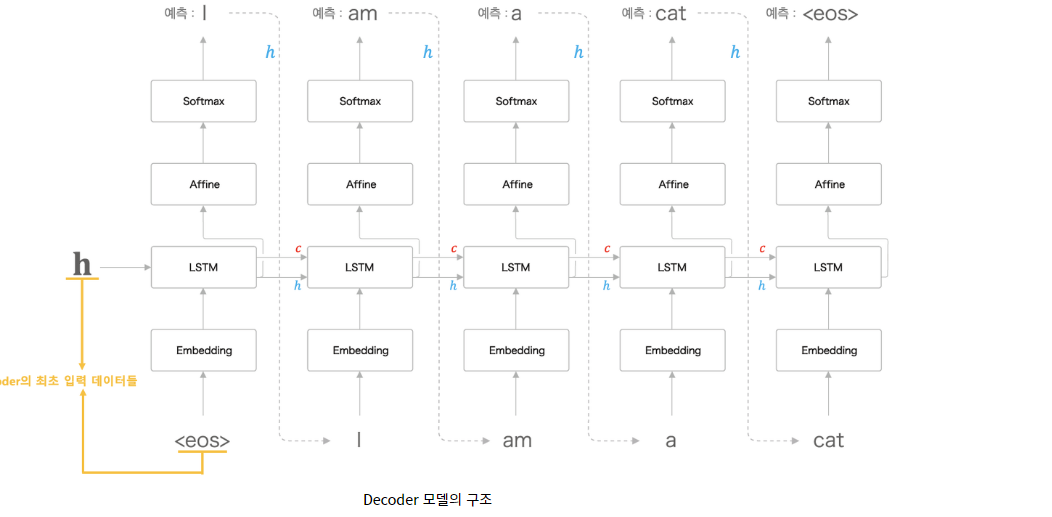

- Decoder 모델에서 최초로 입력되는 데이터로는 Encoder에서 전달해준 ℎ값과 <eos> 기호 사용
- <eos>: 문자의 끝을 알리는 기호
- <eos>는 결국 출발어의 마지막 단어 이자 도착어의 최초 단어를 의미

- seq2seq의 전체 계층 구성

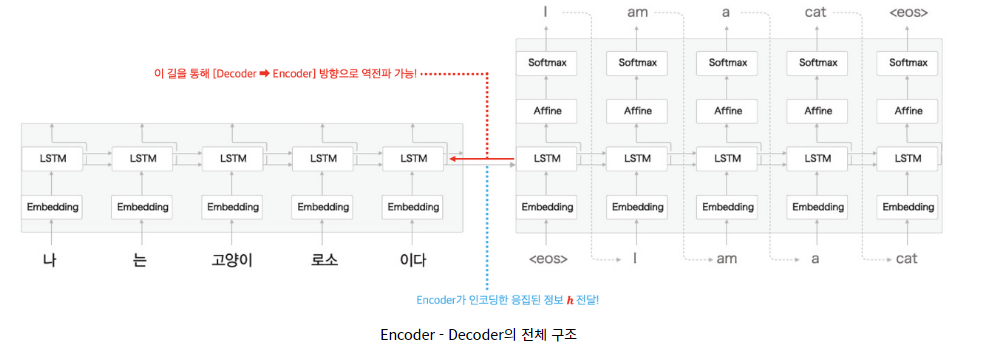

- seq2seq 모델도 역전파를 수행할 때, RNN 처럼 BPTT(Backpropagation Through Time)를 사용
- 순전파를 수행할 때 Encoder가 Decoder에게 전달해주는 ℎ값 덕분에 역전파를 수행할 때도, 이 길을 이용하여 Encoder까지 역전파를 수행할 수 있음

### seq2seq를 이용한 번역기 만들기(2-5 실습)
- http://www.manythings.org/anki

In [3]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### 1. 데이터 벡터화

In [ ]:
fdir='/content/drive/MyDrive/deu2/8. RNN LSTM GRU BERT GPT/data/'
lines = open(fdir+'kor.txt', encoding='utf-8').read().split('\n')
lines[:5]

['Go.\t가.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #8363271 (Eunhee)',
 'Hi.\t안녕.\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #8355888 (Eunhee)',
 'Run!\t뛰어!\tCC-BY 2.0 (France) Attribution: tatoeba.org #906328 (papabear) & #8355891 (Eunhee)',
 'Run.\t뛰어.\tCC-BY 2.0 (France) Attribution: tatoeba.org #4008918 (JSakuragi) & #8363273 (Eunhee)',
 'Who?\t누구?\tCC-BY 2.0 (France) Attribution: tatoeba.org #2083030 (CK) & #6820074 (yesjustryan)']

In [ ]:
# tab 구분기호를 이용해 데이터 분리

num_samples=10000

input_texts=[]
target_texts=[]
input_characters = set()
target_characters = set()

for line in lines[:min(num_samples, len(lines)-1)]:
    # tab(\t)을 기준으로 데이터 나누기
    input_text, target_text, _ = line.split('\t')

    # "\t"문자를 시작 문자로, "\n"문자를 종료 문자로 사용.
    target_text = '\t' + target_text + '\n'
    input_texts.append(input_text)
    target_texts.append(target_text)

     # 문자 집합 생성
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)

len(input_characters),len(target_characters)

(74, 1005)

In [ ]:
input_characters=sorted(input_characters)
target_characters=sorted(target_characters)

# 전체 문장의 갯수 확인
num_encoder_tokens=len(input_characters)
num_decoder_tokens=len(target_characters)

max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

print(f'샘플 데이터 개수: {len(input_texts)}')
print(f'고유 입력 tokens 개수: {num_encoder_tokens}')
print(f'고유 출력 tokens 개수: {num_decoder_tokens}')
print(f'최대 입력 스퀀스 길이 : {max_encoder_seq_length}')
print(f'최대 출력 스퀀스 길이 : {max_decoder_seq_length}')

샘플 데이터 개수: 5749
고유 입력 tokens 개수: 74
고유 출력 tokens 개수: 1005
최대 입력 스퀀스 길이 : 537
최대 출력 스퀀스 길이 : 298


In [ ]:
# 문장 단위 정수 인코딩(문자 -> 숫자 변환용 사전)
input_token_index=dict([(char, i) for i , char in enumerate(input_characters)])
target_token_index=dict([(char, i) for i , char in enumerate(target_characters)])

In [ ]:
# 학습에 사용할 데이터를 담을 3차원 배열
encoder_input_data = np.zeros(
    (num_samples, max_encoder_seq_length, num_encoder_tokens),
    dtype='float32')
decoder_input_data = np.zeros(
    (num_samples, max_decoder_seq_length, num_decoder_tokens),
    dtype='float32')
decoder_target_data = np.zeros(
    (num_samples, max_decoder_seq_length, num_decoder_tokens),
    dtype='float32')

In [ ]:
# 문장을 문자 단위로 원 핫 인코딩하면서 학습용 데이터를 만듬
for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.
    for t, char in enumerate(target_text):
        decoder_input_data[i, t, target_token_index[char]] = 1.
        if t > 0:
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.

In [ ]:
# 인코더 생성
encoder_inputs = Input(shape=(None, num_encoder_tokens))
encoder = LSTM(256, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs)

# 인코더의 출력은 필요없고 상태만 중요
encoder_states = [state_h, state_c] 

In [ ]:
# 디코더 생성.
decoder_inputs = Input(shape=(None, num_decoder_tokens))
decoder_lstm = LSTM(256, return_sequences=True, return_state=True)

# 디코더의 내부 상태는 학습에 사용하지 않지만 추론(테스트) 단계에서는 필요함.
# 디코더의 초기 상태를 인코더의 최종 상태로 설정.
decoder_outputs, _, _ = decoder_lstm(decoder_inputs,
                                     initial_state=encoder_states)
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
# 모델 생성
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy')

In [ ]:
# 학습
model.fit([encoder_input_data, decoder_input_data], decoder_target_data,
          batch_size=4,
          epochs=10,
          validation_split=0.2,
          verbose=1)

Epoch 1/10
2000/2000 [==============================] - 80s 36ms/step - loss: 0.2222 - val_loss: 0.0000e+00
Epoch 2/10
2000/2000 [==============================] - 64s 32ms/step - loss: 0.2198 - val_loss: 0.0000e+00
Epoch 3/10
2000/2000 [==============================] - 64s 32ms/step - loss: 0.2186 - val_loss: 0.0000e+00
Epoch 4/10
2000/2000 [==============================] - 64s 32ms/step - loss: 0.2175 - val_loss: 0.0000e+00
Epoch 5/10
2000/2000 [==============================] - 64s 32ms/step - loss: 0.2166 - val_loss: 0.0000e+00
Epoch 6/10
2000/2000 [==============================] - 64s 32ms/step - loss: 0.2157 - val_loss: 0.0000e+00
Epoch 7/10
2000/2000 [==============================] - 65s 32ms/step - loss: 0.2148 - val_loss: 0.0000e+00
Epoch 8/10
2000/2000 [==============================] - 64s 32ms/step - loss: 0.2141 - val_loss: 0.0000e+00
Epoch 9/10
2000/2000 [==============================] - 65s 32ms/step - loss: 0.2134 - val_loss: 0.0000e+00
Epoch 10/10
2000/2000 [=====

- 추론(테스트)

In [ ]:
# 모델 생성
encoder_model = Model(encoder_inputs, encoder_states)

decoder_state_input_h = Input(shape=(256,))
decoder_state_input_c = Input(shape=(256,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs] + decoder_states_inputs,
                      [decoder_outputs] + decoder_states)

In [ ]:
# 숫자 -> 문자 변환용 사전
reverse_input_char_index = dict(
    (i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict(
    (i, char) for char, i in target_token_index.items())

In [ ]:
def decode_sequence(input_seq):
  # 입력 문장을 인코딩
  states_value = encoder_model.predict(input_seq)
 
  # 디코더의 입력으로 쓸 단일 문자
  target_seq = np.zeros((1, 1, num_decoder_tokens))
  # 첫 입력은 시작 문자인 '\t'로 설정
  target_seq[0, 0, target_token_index['\t']] = 1.
 
  # 문장 생성
  stop_condition = False
  decoded_sentence = ''
  while not stop_condition:
    # 이전의 출력, 상태를 디코더에 넣어서 새로운 출력, 상태를 얻음
    # 이전 문자와 상태로 다음 문자와 상태를 얻는다고 보면 됨.
    output_tokens, h, c = decoder_model.predict(
        [target_seq] + states_value)
 
    # 사전을 사용해서 원 핫 인코딩 출력을 실제 문자로 변환
    sampled_token_index = np.argmax(output_tokens[0, -1, :])
    sampled_char = reverse_target_char_index[sampled_token_index]
    decoded_sentence += sampled_char
 
    # 종료 문자가 나왔거나 문장 길이가 한계를 넘으면 종료
    if (sampled_char == '\n' or len(decoded_sentence) > max_decoder_seq_length):
      stop_condition = True
 
    # 디코더의 다음 입력으로 쓸 데이터 갱신
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    target_seq[0, 0, sampled_token_index] = 1.
    
    states_value = [h, c]
 
  return decoded_sentence

In [ ]:
encoder_input_data[0]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
input_seq = encoder_input_data[0]
decoded_sentence = decode_sequence(input_seq)
print('"{}" -> "{}"'.format(input_texts[seq_index], decoded_sentence.strip()))

InvalidArgumentError: ignored